# Heart Disease Data Analysis

## Project Overview

This project explores clinical and demographic factors associated with heart disease using the UCI Heart Disease dataset.

The analysis focuses on data cleaning, exploratory data analysis (EDA), and visualization using Python, Pandas, NumPy, and Matplotlib.

The goal is to identify meaningful patterns in the dataset while demonstrating a healthcare-focused approach to data analysis.

## Dataset Description

The dataset used in this project is the UCI Heart Disease dataset, specifically the Cleveland subset.

It contains 303 patient records and 14 original variables related to demographic characteristics, clinical measurements, symptoms, and heart disease status.

For this analysis, the original target variable (`num`) was renamed to `target` for clarity. A binary variable called `heart_disease` was then created, where:

- `0` = No heart disease
- `1` = Heart disease present

The dataset contains both categorical and numerical clinical variables, making it suitable for exploratory healthcare data analysis.

## Data Dictionary

| Variable | Description |
|---|---|
| `age` | Age in years |
| `sex` | Sex: 0 = female, 1 = male |
| `cp` | Chest pain type |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl |
| `restecg` | Resting electrocardiographic results |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of the peak exercise ST segment |
| `ca` | Number of major vessels colored by fluoroscopy |
| `thal` | Thalassemia-related result |
| `target` | Original UCI heart disease status code |
| `heart_disease` | Binary heart disease indicator created for this analysis |

## Data Cleaning

The dataset was inspected for missing values, incorrect data types, duplicate records, and potentially invalid values.

### Missing Values

The original dataset represents missing values using `?` rather than standard missing-value indicators.

These values were replaced with `NaN` and converted to numeric values in the `ca` and `thal` columns.

- `ca`: 4 missing values
- `thal`: 2 missing values

The missing values were imputed using the mode of each respective variable.

### Duplicate Records

No duplicate records were identified in the dataset.

### Data Quality Checks

Basic range and category checks were performed for variables such as age, sex, chest pain type, blood pressure, cholesterol, maximum heart rate, and heart disease status.

No obviously invalid values were identified during these basic checks.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

In [20]:
df = pd.read_csv(
    "processed.cleveland.data",
    header=None,
    names=columns
)

In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [23]:
df.shape

(303, 14)

In [27]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [29]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [31]:
df["ca"].unique()

<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str

In [32]:
df["thal"].unique()

<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str

In [34]:
print("Missing ca:", (df["ca"] == "?").sum())
print("Missing thal:", (df["thal"] == "?").sum())

Missing ca: 4
Missing thal: 2


In [36]:
df["ca"].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

In [37]:
df["thal"].value_counts()

thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64

In [39]:
df = df.replace ("?", np.nan)

In [40]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [42]:
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [12]:
print("ca mode:", df["ca"].mode()[0])
print("thal mode:", df["thal"].mode()[0])

ca mode: 0.0
thal mode: 3.0


In [13]:
df[df["ca"].isnull() | df["thal"].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


In [14]:
missing_rows = df[df["ca"].isnull() | df["thal"].isnull()]

missing_rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


In [15]:
print(missing_rows[["age", "ca", "thal", "target"]])

Empty DataFrame
Columns: [age, ca, thal, target]
Index: []


In [16]:
df[["ca", "thal"]].isnull().sum()

ca      0
thal    0
dtype: int64

In [18]:
df.shape

(303, 14)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [20]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [21]:
df["ca"].unique()

<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str

In [23]:
df["thal"].unique()

<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str

In [25]:
print(df["ca"].unique())
print(df["thal"].unique())

<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str
<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [26]:
df = df.replace("?", np.nan)

In [28]:
df[["ca", "thal"]].isnull().sum()

ca      4
thal    2
dtype: int64

In [30]:
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [33]:
print("ca mode:", df["ca"].mode()[0])
print("thal mode:", df["thal"].mode()[0])

ca mode: 0.0
thal mode: 3.0


In [34]:
df["ca"]= df["ca"].fillna(df["ca"].mode()[0])

In [35]:
df["thal"]= df["thal"].fillna(df["thal"].mode()[0])

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [37]:
print("Age range:", df["age"].min(), "-", df["age"].max())
print("Sex values:", df["sex"].unique())
print("Chest pain values:", df["cp"].unique())
print("Target values:", df["target"].unique())

Age range: 29.0 - 77.0
Sex values: [1. 0.]
Chest pain values: [1. 4. 3. 2.]
Target values: [0 2 1 3 4]


In [38]:
df["heart_disease"] = (df["target"] > 0).astype(int)

In [39]:
print("Target values:", df["target"].unique())

Target values: [0 2 1 3 4]


In [40]:
print("Resting BP:", df["trestbps"].min(), "-", df["trestbps"].max())
print("Cholesterol:", df["chol"].min(), "-", df["chol"].max())
print("Max Heart Rate:", df["thalach"].min(), "-", df["thalach"].max())
print("Oldpeak:", df["oldpeak"].min(), "-", df["oldpeak"].max())

Resting BP: 94.0 - 200.0
Cholesterol: 126.0 - 564.0
Max Heart Rate: 71.0 - 202.0
Oldpeak: 0.0 - 6.2


In [41]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [42]:
df["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [45]:
df["target"].value_counts(normalize=True)*100

target
0    54.125413
1    18.151815
2    11.881188
3    11.551155
4     4.290429
Name: proportion, dtype: float64

In [46]:
df.groupby("sex")["target"].value_counts()

sex  target
0.0  0         72
     1          9
     3          7
     2          7
     4          2
1.0  0         92
     1         46
     2         29
     3         28
     4         11
Name: count, dtype: int64

In [47]:
pd.crosstab(
    df["sex"],
    df["target"],
    normalize="index"
) * 100

target,0,1,2,3,4
sex,,,,,
0.0,74.226804,9.278351,7.216495,7.216495,2.061856
1.0,44.660194,22.330097,14.077670,13.592233,5.339806


# Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to identify patterns and relationships between heart disease presence and selected demographic and clinical variables.

In [48]:
df["heart_disease"] = (df["target"] > 0).astype(int)

## Heart Disease by Sex

This analysis examines the proportion of patients with heart disease across sex categories.

In [49]:
df.groupby("sex")["heart_disease"].mean() * 100

sex
0.0    25.773196
1.0    55.339806
Name: heart_disease, dtype: float64

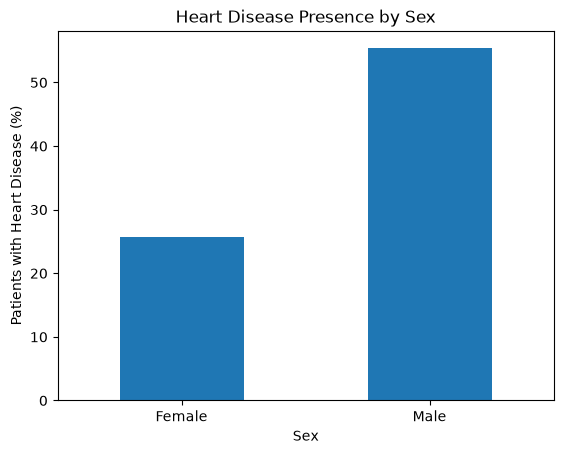

In [3]:
sex_disease = df.groupby("sex")["heart_disease"].mean() * 100

sex_disease.index = ["Female", "Male"]

sex_disease.plot(kind="bar")

plt.title("Heart Disease Presence by Sex")
plt.xlabel("Sex")
plt.ylabel("Patients with Heart Disease (%)")
plt.xticks(rotation=0)
plt.show()

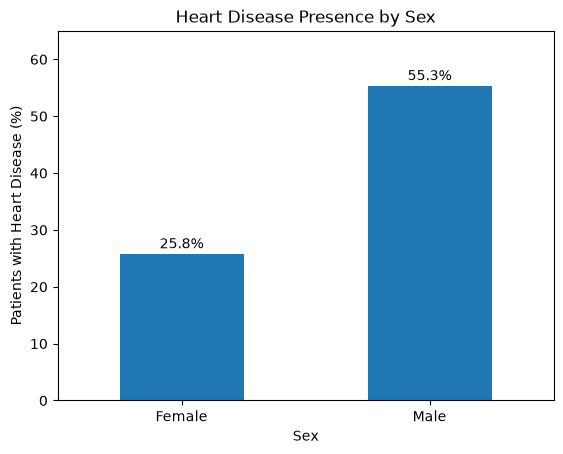

In [4]:
sex_disease = df.groupby("sex")["heart_disease"].mean() * 100
sex_disease.index = ["Female", "Male"]

ax = sex_disease.plot(kind="bar")

plt.title("Heart Disease Presence by Sex")
plt.xlabel("Sex")
plt.ylabel("Patients with Heart Disease (%)")
plt.xticks(rotation=0)

for i, value in enumerate(sex_disease):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 65)
plt.show()

## Age Distribution by Heart Disease Status

Age was compared between patients with and without heart disease using descriptive statistics and a box plot.

In [3]:
df["age"].describe()

count    303.000000
mean      54.438944
std        9.038662
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

In [4]:
df.groupby("heart_disease")["age"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
heart_disease,,,,,
0,164,52.585366,52.0,29.0,76.0
1,139,56.625899,58.0,35.0,77.0


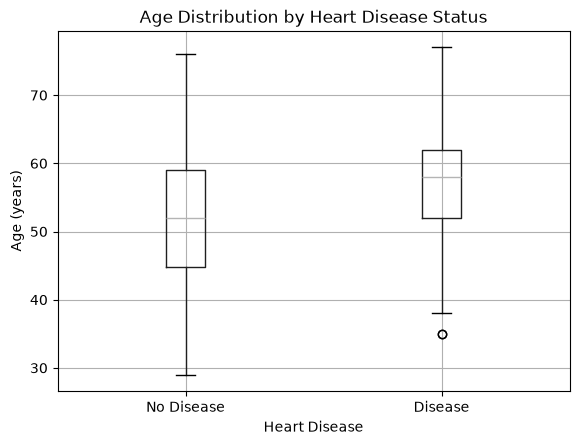

In [5]:
df.boxplot(
    column="age",
    by="heart_disease"
)

plt.title("Age Distribution by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Age (years)")
plt.xticks([1, 2], ["No Disease", "Disease"])

plt.show()

## Heart Disease by Chest Pain Type

The distribution of heart disease presence was examined across different chest pain categories.

In [6]:
df.groupby("cp")["heart_disease"].agg(["count", "mean"])

,count,mean
cp,,
1.0,23,0.304348
2.0,50,0.180000
3.0,86,0.209302
4.0,144,0.729167


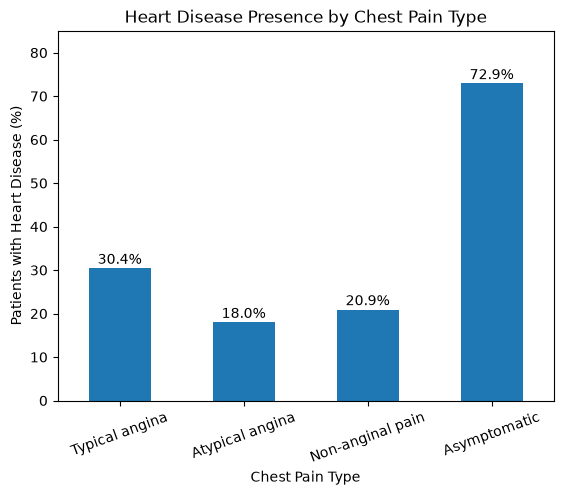

In [7]:
cp_disease = df.groupby("cp")["heart_disease"].mean() * 100

cp_disease.index = [
    "Typical angina",
    "Atypical angina",
    "Non-anginal pain",
    "Asymptomatic"
]

ax = cp_disease.plot(kind="bar")

plt.title("Heart Disease Presence by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Patients with Heart Disease (%)")
plt.xticks(rotation=20)

for i, value in enumerate(cp_disease):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 85)
plt.show()

## Maximum Heart Rate by Heart Disease Status

Maximum heart rate achieved (`thalach`) was compared between patients with and without heart disease using descriptive statistics and a box plot.

In [8]:
df.groupby("heart_disease")["thalach"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
heart_disease,,,,,
0,164,158.378049,161.0,96.0,202.0
1,139,139.258993,142.0,71.0,195.0


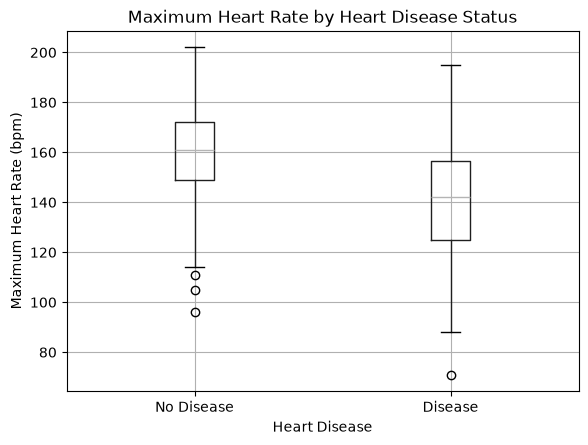

In [9]:
df.boxplot(
    column="thalach",
    by="heart_disease"
)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate (bpm)")
plt.xticks([1, 2], ["No Disease", "Disease"])

plt.show()

## Key Clinical Insights

1. **Heart disease and sex**
   In this dataset, heart disease was more frequently observed among male patients than female patients. The proportion of patients with heart disease was approximately 55.3% among males compared with 25.8% among females.

2. **Heart disease and age**
   Patients with heart disease had a higher average age than those without heart disease (56.6 vs. 52.6 years). This indicates an association between age and heart disease presence within this dataset.

3. **Chest pain pattern**
   The prevalence of heart disease varied substantially across chest pain categories. The highest proportion was observed among patients classified as asymptomatic (72.9%), while the other categories ranged from 18.0% to 30.4%.

4. **Maximum heart rate**
   Patients with heart disease had a lower average maximum heart rate than patients without heart disease (139.3 vs. 158.4 bpm). The median values showed a similar pattern (142 vs. 161 bpm).

## Limitations

- This analysis is based on a single dataset containing 303 patient records, so the findings should not be generalized to the broader population.

- The analysis is observational and identifies associations between variables and heart disease presence. It does not establish causal relationships.

- Missing values in the `ca` and `thal` variables were replaced using the mode. Although this allowed us to complete the analysis, imputation may introduce some bias.

- The original UCI heart disease target contains multiple disease-status codes (0–4). For this analysis, these were converted into a binary variable where `0` represents no heart disease and values greater than `0` represent heart disease presence.

- The analysis focuses on descriptive statistics and visual exploration. No statistical significance testing or predictive machine learning model was performed.